<a href="https://colab.research.google.com/github/Bhargavi-kokk/C-/blob/main/Food_Delivery_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#MODULE 1 – PROJECT SETUP AND DATASET LOADING


In [2]:
# ============================================================
# MODULE 1 - PROJECT SETUP AND DATASET LOADING
# ============================================================

# Import basic libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# For interactive widgets / filters
from ipywidgets import interact, widgets

# Machine learning libraries (we will use later)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Load dataset
df = pd.read_csv('/content/zomato.csv')

# Show first 5 rows
df.head()

,Unnamed: 0.1,Unnamed: 0,restaurant name,restaurant type,rate (out of 5),num of ratings,avg cost (two people),online_order,table booking,cuisines type,area,local address
0,0,0,#FeelTheROLL,Quick Bites,3.4,7,200.0,No,No,Fast Food,Bellandur,Bellandur
1,1,1,#L-81 Cafe,Quick Bites,3.9,48,400.0,Yes,No,"Fast Food, Beverages","Byresandra,Tavarekere,Madiwala",HSR
2,2,2,#refuel,Cafe,3.7,37,400.0,Yes,No,"Cafe, Beverages",Bannerghatta Road,Bannerghatta Road
3,3,3,'@ Biryani Central,Casual Dining,2.7,135,550.0,Yes,No,"Biryani, Mughlai, Chinese",Marathahalli,Marathahalli
4,4,4,'@ The Bbq,Casual Dining,2.8,40,700.0,Yes,No,"BBQ, Continental, North Indian, Chinese, Bever...",Bellandur,Bellandur


#MODULE 2 – DATASET UNDERSTANDING

In [3]:
# ============================================================
# MODULE 2 - DATASET UNDERSTANDING
# ============================================================

# Shape of dataset
print("Shape of dataset:", df.shape)

# Column names
print("\nColumns in dataset:")
print(df.columns)

# First 5 rows
print("\nFirst 5 rows of dataset:")
display(df.head())

# Last 5 rows
print("\nLast 5 rows of dataset:")
display(df.tail())

# Information about dataset
print("\nDataset Information:")
df.info()

# Missing values
print("\nMissing values in each column:")
display(df.isnull().sum())

# Statistical summary
print("\nStatistical summary of numerical columns:")
display(df.describe())

# Statistical summary including categorical columns
print("\nOverall summary including categorical columns:")
display(df.describe(include='all'))

Shape of dataset: (7105, 12)

Columns in dataset:
Index(['Unnamed: 0.1', 'Unnamed: 0', 'restaurant name', 'restaurant type',
       'rate (out of 5)', 'num of ratings', 'avg cost (two people)',
       'online_order', 'table booking', 'cuisines type', 'area',
       'local address'],
      dtype='object')

First 5 rows of dataset:


,Unnamed: 0.1,Unnamed: 0,restaurant name,restaurant type,rate (out of 5),num of ratings,avg cost (two people),online_order,table booking,cuisines type,area,local address
0,0,0,#FeelTheROLL,Quick Bites,3.4,7,200.0,No,No,Fast Food,Bellandur,Bellandur
1,1,1,#L-81 Cafe,Quick Bites,3.9,48,400.0,Yes,No,"Fast Food, Beverages","Byresandra,Tavarekere,Madiwala",HSR
2,2,2,#refuel,Cafe,3.7,37,400.0,Yes,No,"Cafe, Beverages",Bannerghatta Road,Bannerghatta Road
3,3,3,'@ Biryani Central,Casual Dining,2.7,135,550.0,Yes,No,"Biryani, Mughlai, Chinese",Marathahalli,Marathahalli
4,4,4,'@ The Bbq,Casual Dining,2.8,40,700.0,Yes,No,"BBQ, Continental, North Indian, Chinese, Bever...",Bellandur,Bellandur



Last 5 rows of dataset:


,Unnamed: 0.1,Unnamed: 0,restaurant name,restaurant type,rate (out of 5),num of ratings,avg cost (two people),online_order,table booking,cuisines type,area,local address
7100,7100,7100,Zoey's,Cafe,4.3,894,600.0,Yes,No,"Cafe, Italian, Continental, Burger",Bellandur,Sarjapur Road
7101,7101,7101,ZOROY Luxury Chocolate,Dessert Parlor,4.0,68,250.0,Yes,No,Desserts,Brigade Road,Church Street
7102,7102,7102,Zu's Doner Kebaps,"Takeaway, Delivery",3.7,33,350.0,No,No,"Turkish, Fast Food, Biryani, Chinese",Malleshwaram,RT Nagar
7103,7103,7103,Zyara,Casual Dining,3.8,191,650.0,Yes,No,"North Indian, Mughlai, Chinese",Kammanahalli,HBR Layout
7104,7104,7104,Zyksha,Food Truck,3.4,9,200.0,No,No,Fast Food,Bannerghatta Road,South Bangalore



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7105 entries, 0 to 7104
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Unnamed: 0.1           7105 non-null   int64  
 1   Unnamed: 0             7105 non-null   int64  
 2   restaurant name        7105 non-null   object 
 3   restaurant type        7105 non-null   object 
 4   rate (out of 5)        7037 non-null   float64
 5   num of ratings         7105 non-null   int64  
 6   avg cost (two people)  7048 non-null   float64
 7   online_order           7105 non-null   object 
 8   table booking          7105 non-null   object 
 9   cuisines type          7105 non-null   object 
 10  area                   7105 non-null   object 
 11  local address          7105 non-null   object 
dtypes: float64(2), int64(3), object(7)
memory usage: 666.2+ KB

Missing values in each column:


,0
Unnamed: 0.1,0
Unnamed: 0,0
restaurant name,0
restaurant type,0
rate (out of 5),68
num of ratings,0
avg cost (two people),57
online_order,0
table booking,0
cuisines type,0



Statistical summary of numerical columns:


,Unnamed: 0.1,Unnamed: 0,rate (out of 5),num of ratings,avg cost (two people)
count,7105.000000,7105.000000,7037.000000,7105.000000,7048.000000
mean,3552.000000,3552.000000,3.514253,188.921042,540.286464
std,2051.181164,2051.181164,0.463249,592.171049,462.902305
min,0.000000,0.000000,1.800000,1.000000,40.000000
25%,1776.000000,1776.000000,3.200000,16.000000,300.000000
50%,3552.000000,3552.000000,3.500000,40.000000,400.000000
75%,5328.000000,5328.000000,3.800000,128.000000,600.000000
max,7104.000000,7104.000000,4.900000,16345.000000,6000.000000



Overall summary including categorical columns:


,Unnamed: 0.1,Unnamed: 0,restaurant name,restaurant type,rate (out of 5),num of ratings,avg cost (two people),online_order,table booking,cuisines type,area,local address
count,7105.000000,7105.000000,7105,7105,7037.000000,7105.000000,7048.000000,7105,7105,7105,7105,7105
unique,NaN,NaN,7105,81,NaN,NaN,NaN,2,2,2175,30,90
top,NaN,NaN,Zyksha,Quick Bites,NaN,NaN,NaN,Yes,No,"North Indian, Chinese","Byresandra,Tavarekere,Madiwala",Whitefield
freq,NaN,NaN,1,2840,NaN,NaN,NaN,3727,6361,421,798,459
mean,3552.000000,3552.000000,NaN,NaN,3.514253,188.921042,540.286464,NaN,NaN,NaN,NaN,NaN
std,2051.181164,2051.181164,NaN,NaN,0.463249,592.171049,462.902305,NaN,NaN,NaN,NaN,NaN
min,0.000000,0.000000,NaN,NaN,1.800000,1.000000,40.000000,NaN,NaN,NaN,NaN,NaN
25%,1776.000000,1776.000000,NaN,NaN,3.200000,16.000000,300.000000,NaN,NaN,NaN,NaN,NaN
50%,3552.000000,3552.000000,NaN,NaN,3.500000,40.000000,400.000000,NaN,NaN,NaN,NaN,NaN
75%,5328.000000,5328.000000,NaN,NaN,3.800000,128.000000,600.000000,NaN,NaN,NaN,NaN,NaN


#Module 3 - Data Cleaning and Preprocessing



3.1 Cleaning dataset

In [4]:
df_clean = df.copy()
df_clean.head()

,Unnamed: 0.1,Unnamed: 0,restaurant name,restaurant type,rate (out of 5),num of ratings,avg cost (two people),online_order,table booking,cuisines type,area,local address
0,0,0,#FeelTheROLL,Quick Bites,3.4,7,200.0,No,No,Fast Food,Bellandur,Bellandur
1,1,1,#L-81 Cafe,Quick Bites,3.9,48,400.0,Yes,No,"Fast Food, Beverages","Byresandra,Tavarekere,Madiwala",HSR
2,2,2,#refuel,Cafe,3.7,37,400.0,Yes,No,"Cafe, Beverages",Bannerghatta Road,Bannerghatta Road
3,3,3,'@ Biryani Central,Casual Dining,2.7,135,550.0,Yes,No,"Biryani, Mughlai, Chinese",Marathahalli,Marathahalli
4,4,4,'@ The Bbq,Casual Dining,2.8,40,700.0,Yes,No,"BBQ, Continental, North Indian, Chinese, Bever...",Bellandur,Bellandur


3.2 – Remove unwanted columns

In [5]:
df_clean.drop(['Unnamed: 0.1', 'Unnamed: 0'], axis=1, inplace=True, errors='ignore')
print(df_clean.columns)

Index(['restaurant name', 'restaurant type', 'rate (out of 5)',
       'num of ratings', 'avg cost (two people)', 'online_order',
       'table booking', 'cuisines type', 'area', 'local address'],
      dtype='object')


3.3 – Rename columns

In [6]:
df_clean.rename(columns={
    'restaurant name': 'restaurant_name',
    'restaurant type': 'restaurant_type',
    'rate (out of 5)': 'rating',
    'num of ratings': 'num_ratings',
    'avg cost (two people)': 'avg_cost_for_two',
    'table booking': 'table_booking',
    'cuisines type': 'cuisines_type',
    'local address': 'local_address'
}, inplace=True)

print(df_clean.columns)

Index(['restaurant_name', 'restaurant_type', 'rating', 'num_ratings',
       'avg_cost_for_two', 'online_order', 'table_booking', 'cuisines_type',
       'area', 'local_address'],
      dtype='object')


3.4 Check Duplicate Rows and Remove Them

In [7]:
# ============================================================
# 3.4 CHECK AND REMOVE DUPLICATES
# ============================================================

print("Shape before removing duplicates:", df_clean.shape)

duplicate_count = df_clean.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)

df_clean.drop_duplicates(inplace=True)

print("Shape after removing duplicates:", df_clean.shape)

Shape before removing duplicates: (7105, 10)
Number of duplicate rows: 0
Shape after removing duplicates: (7105, 10)


3.5 Check Missing Values Before Cleaning

In [8]:
# ============================================================
# 3.5 CHECK MISSING VALUES BEFORE CLEANING
# ============================================================

missing_before = df_clean.isnull().sum().sort_values(ascending=False)

print("Missing values before cleaning:")
display(missing_before[missing_before > 0])

Missing values before cleaning:


,0
rating,68
avg_cost_for_two,57


3.6 Clean Text Columns

In [9]:
# ============================================================
# 3.6 CLEAN TEXT COLUMNS
# ============================================================

text_columns = ['restaurant_name', 'restaurant_type', 'online_order',
                'table_booking', 'cuisines_type', 'area', 'local_address']

for col in text_columns:
    df_clean[col] = df_clean[col].astype(str).str.strip()

print("Text columns cleaned successfully.")
display(df_clean[text_columns].head())

Text columns cleaned successfully.


,restaurant_name,restaurant_type,online_order,table_booking,cuisines_type,area,local_address
0,#FeelTheROLL,Quick Bites,No,No,Fast Food,Bellandur,Bellandur
1,#L-81 Cafe,Quick Bites,Yes,No,"Fast Food, Beverages","Byresandra,Tavarekere,Madiwala",HSR
2,#refuel,Cafe,Yes,No,"Cafe, Beverages",Bannerghatta Road,Bannerghatta Road
3,'@ Biryani Central,Casual Dining,Yes,No,"Biryani, Mughlai, Chinese",Marathahalli,Marathahalli
4,'@ The Bbq,Casual Dining,Yes,No,"BBQ, Continental, North Indian, Chinese, Bever...",Bellandur,Bellandur


3.7 Convert Numeric Columns

In [10]:
# ============================================================
# 3.7 CONVERT NUMERIC COLUMNS
# ============================================================

# Check data types before conversion
print("Data types before conversion:")
print(df_clean[['rating', 'num_ratings', 'avg_cost_for_two']].dtypes)

# Convert to numeric
df_clean['rating'] = pd.to_numeric(df_clean['rating'], errors='coerce')
df_clean['num_ratings'] = pd.to_numeric(df_clean['num_ratings'], errors='coerce')
df_clean['avg_cost_for_two'] = pd.to_numeric(df_clean['avg_cost_for_two'], errors='coerce')

print("\nData types after conversion:")
print(df_clean[['rating', 'num_ratings', 'avg_cost_for_two']].dtypes)

print("\nNull values after numeric conversion:")
print(df_clean[['rating', 'num_ratings', 'avg_cost_for_two']].isnull().sum())

Data types before conversion:
rating              float64
num_ratings           int64
avg_cost_for_two    float64
dtype: object

Data types after conversion:
rating              float64
num_ratings           int64
avg_cost_for_two    float64
dtype: object

Null values after numeric conversion:
rating              68
num_ratings          0
avg_cost_for_two    57
dtype: int64


3.8 Standardize Categorical Columns

In [11]:
# ============================================================
# 3.8 STANDARDIZE CATEGORICAL COLUMNS
# ============================================================

df_clean['online_order'] = df_clean['online_order'].astype(str).str.strip().str.lower()
df_clean['table_booking'] = df_clean['table_booking'].astype(str).str.strip().str.lower()

print("Unique values in online_order:")
print(df_clean['online_order'].unique())

print("\nUnique values in table_booking:")
print(df_clean['table_booking'].unique())

Unique values in online_order:
['no' 'yes']

Unique values in table_booking:
['no' 'yes']


3.9 Handle Missing Values

In [12]:
# ============================================================
# 3.9 HANDLE MISSING VALUES
# ============================================================

# Fill numerical columns with median
df_clean['rating'].fillna(df_clean['rating'].median(), inplace=True)
df_clean['num_ratings'].fillna(df_clean['num_ratings'].median(), inplace=True)
df_clean['avg_cost_for_two'].fillna(df_clean['avg_cost_for_two'].median(), inplace=True)

# Fill categorical columns with mode
df_clean['restaurant_type'].fillna(df_clean['restaurant_type'].mode()[0], inplace=True)
df_clean['cuisines_type'].fillna(df_clean['cuisines_type'].mode()[0], inplace=True)
df_clean['area'].fillna(df_clean['area'].mode()[0], inplace=True)

print("Missing values after handling:")
display(df_clean.isnull().sum())

Missing values after handling:


,0
restaurant_name,0
restaurant_type,0
rating,0
num_ratings,0
avg_cost_for_two,0
online_order,0
table_booking,0
cuisines_type,0
area,0
local_address,0


3.10 Validate the Cleaned Dataset

In [13]:
# ============================================================
# 3.10 VALIDATE CLEANED DATASET
# ============================================================

print("Final cleaned dataset shape:", df_clean.shape)

print("\nDataset info:")
df_clean.info()

print("\nFirst 5 rows of cleaned dataset:")
display(df_clean.head())

print("\nRandom sample rows:")
display(df_clean.sample(5))

Final cleaned dataset shape: (7105, 10)

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7105 entries, 0 to 7104
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   restaurant_name   7105 non-null   object 
 1   restaurant_type   7105 non-null   object 
 2   rating            7105 non-null   float64
 3   num_ratings       7105 non-null   int64  
 4   avg_cost_for_two  7105 non-null   float64
 5   online_order      7105 non-null   object 
 6   table_booking     7105 non-null   object 
 7   cuisines_type     7105 non-null   object 
 8   area              7105 non-null   object 
 9   local_address     7105 non-null   object 
dtypes: float64(2), int64(1), object(7)
memory usage: 555.2+ KB

First 5 rows of cleaned dataset:


,restaurant_name,restaurant_type,rating,num_ratings,avg_cost_for_two,online_order,table_booking,cuisines_type,area,local_address
0,#FeelTheROLL,Quick Bites,3.4,7,200.0,no,no,Fast Food,Bellandur,Bellandur
1,#L-81 Cafe,Quick Bites,3.9,48,400.0,yes,no,"Fast Food, Beverages","Byresandra,Tavarekere,Madiwala",HSR
2,#refuel,Cafe,3.7,37,400.0,yes,no,"Cafe, Beverages",Bannerghatta Road,Bannerghatta Road
3,'@ Biryani Central,Casual Dining,2.7,135,550.0,yes,no,"Biryani, Mughlai, Chinese",Marathahalli,Marathahalli
4,'@ The Bbq,Casual Dining,2.8,40,700.0,yes,no,"BBQ, Continental, North Indian, Chinese, Bever...",Bellandur,Bellandur



Random sample rows:


,restaurant_name,restaurant_type,rating,num_ratings,avg_cost_for_two,online_order,table_booking,cuisines_type,area,local_address
6772,Up Bhavan,Sweet Shop,3.4,6,150.0,no,no,"Mithai, Street Food",Brigade Road,Commercial Street
1325,C-harge by Chefkraft,Cafe,3.4,7,600.0,no,no,"Cafe, Continental",Indiranagar,Indiranagar
6031,Taipan,Casual Dining,3.5,126,700.0,yes,no,"Chinese, Momos",Brigade Road,Frazer Town
1700,Darbar,Bar,3.0,98,800.0,no,no,"North Indian, Chinese",Banashankari,Banashankari
4734,Pizza Paradise,Quick Bites,3.5,61,500.0,yes,no,Pizza,Jayanagar,JP Nagar


3.11 Save Cleaned Dataset

> Add blockquote



In [14]:
# ============================================================
# 3.11 SAVE CLEANED DATASET
# ============================================================

df_clean.to_csv('/content/zomato_cleaned.csv', index=False)
print("Cleaned dataset saved successfully as 'zomato_cleaned.csv'")

Cleaned dataset saved successfully as 'zomato_cleaned.csv'


#MODULE 4 – FEATURE ENGINEERING

## 4.1 Create Rating Category

In [15]:
# ============================================================
# 4.1 CREATE RATING CATEGORY
# ============================================================

def rating_category(rating):
    if rating < 3.5:
        return 'Low Rated'
    elif rating < 4.0:
        return 'Average Rated'
    else:
        return 'Highly Rated'

df_clean['rating_category'] = df_clean['rating'].apply(rating_category)

print("Rating category created successfully.")
print(df_clean['rating_category'].value_counts())

display(df_clean[['restaurant_name', 'rating', 'rating_category']].head())

Rating category created successfully.
rating_category
Low Rated        3052
Average Rated    2803
Highly Rated     1250
Name: count, dtype: int64


,restaurant_name,rating,rating_category
0,#FeelTheROLL,3.4,Low Rated
1,#L-81 Cafe,3.9,Average Rated
2,#refuel,3.7,Average Rated
3,'@ Biryani Central,2.7,Low Rated
4,'@ The Bbq,2.8,Low Rated


## 4.2 Create Cost Category

In [16]:
# ============================================================
# 4.2 CREATE COST CATEGORY
# ============================================================

def cost_category(cost):
    if cost <= 300:
        return 'Budget'
    elif cost <= 600:
        return 'Mid-range'
    else:
        return 'Expensive'

df_clean['cost_category'] = df_clean['avg_cost_for_two'].apply(cost_category)

print("Cost category created successfully.")
print(df_clean['cost_category'].value_counts())

display(df_clean[['restaurant_name', 'avg_cost_for_two', 'cost_category']].head())

Cost category created successfully.
cost_category
Budget       2708
Mid-range    2707
Expensive    1690
Name: count, dtype: int64


,restaurant_name,avg_cost_for_two,cost_category
0,#FeelTheROLL,200.0,Budget
1,#L-81 Cafe,400.0,Mid-range
2,#refuel,400.0,Mid-range
3,'@ Biryani Central,550.0,Mid-range
4,'@ The Bbq,700.0,Expensive


4.3 Create Popularity Category

In [17]:
# ============================================================
# 4.3 CREATE POPULARITY CATEGORY
# ============================================================

def popularity_category(num):
    if num <= 100:
        return 'Low Popularity'
    elif num <= 500:
        return 'Medium Popularity'
    else:
        return 'High Popularity'

df_clean['popularity_category'] = df_clean['num_ratings'].apply(popularity_category)

print("Popularity category created successfully.")
print(df_clean['popularity_category'].value_counts())

display(df_clean[['restaurant_name', 'num_ratings', 'popularity_category']].head())

Popularity category created successfully.
popularity_category
Low Popularity       5059
Medium Popularity    1459
High Popularity       587
Name: count, dtype: int64


,restaurant_name,num_ratings,popularity_category
0,#FeelTheROLL,7,Low Popularity
1,#L-81 Cafe,48,Low Popularity
2,#refuel,37,Low Popularity
3,'@ Biryani Central,135,Medium Popularity
4,'@ The Bbq,40,Low Popularity


## 4.4 Create Online Order Flag

In [18]:
# ============================================================
# 4.4 CREATE ONLINE ORDER FLAG
# ============================================================

df_clean['online_order_flag'] = df_clean['online_order'].map({'yes': 1, 'no': 0})

print("Online order flag created.")
print(df_clean[['online_order', 'online_order_flag']].head())

Online order flag created.
  online_order  online_order_flag
0           no                  0
1          yes                  1
2          yes                  1
3          yes                  1
4          yes                  1


## 4.5 Create Table Booking Flag

In [19]:
# ============================================================
# 4.5 CREATE TABLE BOOKING FLAG
# ============================================================

df_clean['table_booking_flag'] = df_clean['table_booking'].map({'yes': 1, 'no': 0})

print("Table booking flag created.")
print(df_clean[['table_booking', 'table_booking_flag']].head())

Table booking flag created.
  table_booking  table_booking_flag
0            no                   0
1            no                   0
2            no                   0
3            no                   0
4            no                   0


4.6 Create High Rated Target Column for ML

In [20]:
# ============================================================
# 4.6 CREATE TARGET VARIABLE FOR MACHINE LEARNING
# ============================================================

df_clean['is_high_rated'] = df_clean['rating'].apply(lambda x: 1 if x >= 4.0 else 0)

print("Target column 'is_high_rated' created successfully.")
print(df_clean['is_high_rated'].value_counts())

display(df_clean[['restaurant_name', 'rating', 'is_high_rated']].head())

Target column 'is_high_rated' created successfully.
is_high_rated
0    5855
1    1250
Name: count, dtype: int64


,restaurant_name,rating,is_high_rated
0,#FeelTheROLL,3.4,0
1,#L-81 Cafe,3.9,0
2,#refuel,3.7,0
3,'@ Biryani Central,2.7,0
4,'@ The Bbq,2.8,0


4.7 Validate Newly Created Features

In [21]:
# ============================================================
# 4.7 VALIDATE NEW FEATURES
# ============================================================

new_columns = [
    'rating_category',
    'cost_category',
    'popularity_category',
    'online_order_flag',
    'table_booking_flag',
    'is_high_rated'
]

print("Newly created columns:")
print(df_clean[new_columns].head())

print("\nDataset shape after feature engineering:", df_clean.shape)
print("\nAll columns in dataset:")
print(df_clean.columns.tolist())

Newly created columns:
  rating_category cost_category popularity_category  online_order_flag  \
0       Low Rated        Budget      Low Popularity                  0   
1   Average Rated     Mid-range      Low Popularity                  1   
2   Average Rated     Mid-range      Low Popularity                  1   
3       Low Rated     Mid-range   Medium Popularity                  1   
4       Low Rated     Expensive      Low Popularity                  1   

   table_booking_flag  is_high_rated  
0                   0              0  
1                   0              0  
2                   0              0  
3                   0              0  
4                   0              0  

Dataset shape after feature engineering: (7105, 16)

All columns in dataset:
['restaurant_name', 'restaurant_type', 'rating', 'num_ratings', 'avg_cost_for_two', 'online_order', 'table_booking', 'cuisines_type', 'area', 'local_address', 'rating_category', 'cost_category', 'popularity_category', 'o

4.8 Save Dataset After Feature Engineering

In [22]:
# ============================================================
# 4.8 SAVE FEATURE ENGINEERED DATASET
# ============================================================

df_clean.to_csv('/content/zomato_feature_engineered.csv', index=False)
print("Feature-engineered dataset saved as 'zomato_feature_engineered.csv'")

Feature-engineered dataset saved as 'zomato_feature_engineered.csv'


# MODULE 5 – EXPLORATORY DATA ANALYSIS (EDA)

Shape of dataset: (7105, 16)

Columns:
['restaurant_name', 'restaurant_type', 'rating', 'num_ratings', 'avg_cost_for_two', 'online_order', 'table_booking', 'cuisines_type', 'area', 'local_address', 'rating_category', 'cost_category', 'popularity_category', 'online_order_flag', 'table_booking_flag', 'is_high_rated']


,restaurant_name,restaurant_type,rating,num_ratings,avg_cost_for_two,online_order,table_booking,cuisines_type,area,local_address,rating_category,cost_category,popularity_category,online_order_flag,table_booking_flag,is_high_rated
0,#FeelTheROLL,Quick Bites,3.4,7,200.0,no,no,Fast Food,Bellandur,Bellandur,Low Rated,Budget,Low Popularity,0,0,0
1,#L-81 Cafe,Quick Bites,3.9,48,400.0,yes,no,"Fast Food, Beverages","Byresandra,Tavarekere,Madiwala",HSR,Average Rated,Mid-range,Low Popularity,1,0,0
2,#refuel,Cafe,3.7,37,400.0,yes,no,"Cafe, Beverages",Bannerghatta Road,Bannerghatta Road,Average Rated,Mid-range,Low Popularity,1,0,0
3,'@ Biryani Central,Casual Dining,2.7,135,550.0,yes,no,"Biryani, Mughlai, Chinese",Marathahalli,Marathahalli,Low Rated,Mid-range,Medium Popularity,1,0,0
4,'@ The Bbq,Casual Dining,2.8,40,700.0,yes,no,"BBQ, Continental, North Indian, Chinese, Bever...",Bellandur,Bellandur,Low Rated,Expensive,Low Popularity,1,0,0



Top restaurant types:


,count
restaurant_type,
Quick Bites,2840
Casual Dining,1634
Cafe,403
Delivery,358
"Takeaway, Delivery",289
Dessert Parlor,217
Bakery,154
"Casual Dining, Bar",123
Beverage Shop,118


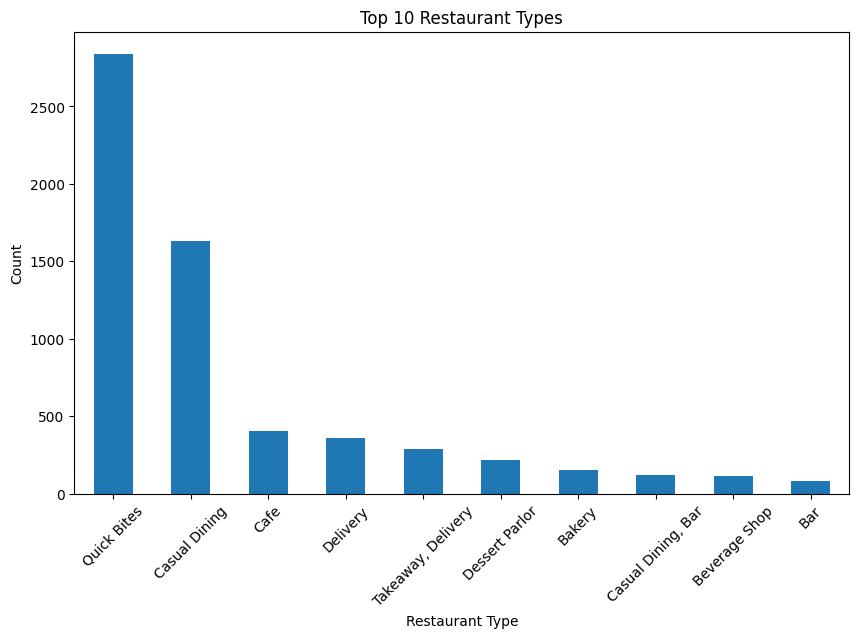


Online order distribution:


,count
online_order,
yes,3727
no,3378


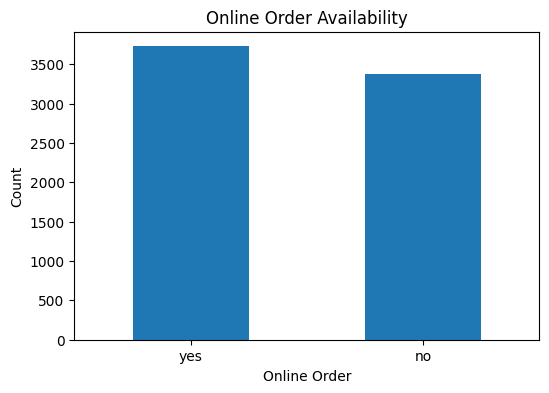


Table booking distribution:


,count
table_booking,
no,6361
yes,744


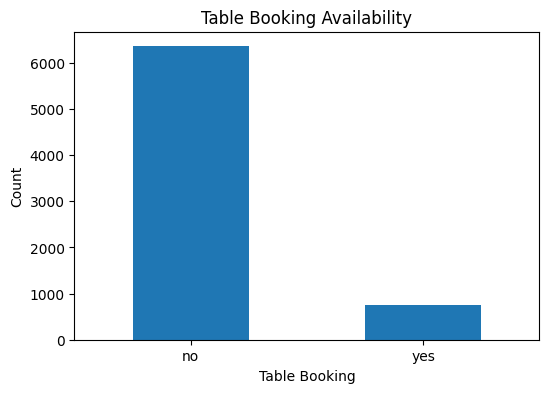


Top 10 areas:


,count
area,
"Byresandra,Tavarekere,Madiwala",798
Bannerghatta Road,552
Brookefield,477
Brigade Road,464
Indiranagar,455
Electronic City,403
Malleshwaram,402
Kalyan Nagar,384
Bellandur,361


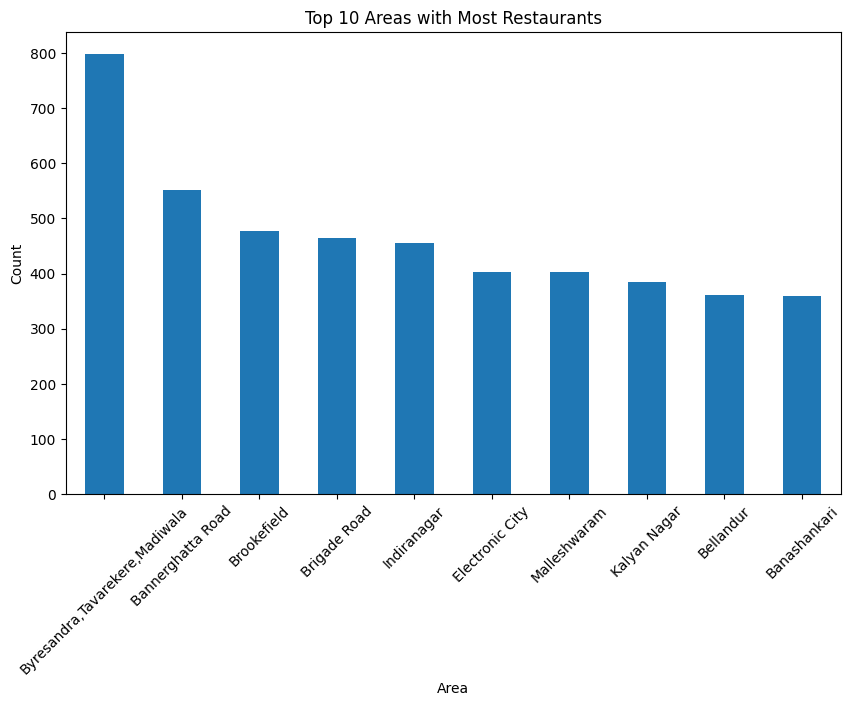


Top 10 cuisines:


,count
North Indian,3237
Chinese,2438
South Indian,1464
Fast Food,1037
Biryani,929
Continental,738
Desserts,543
Beverages,533
Cafe,519
Street Food,394


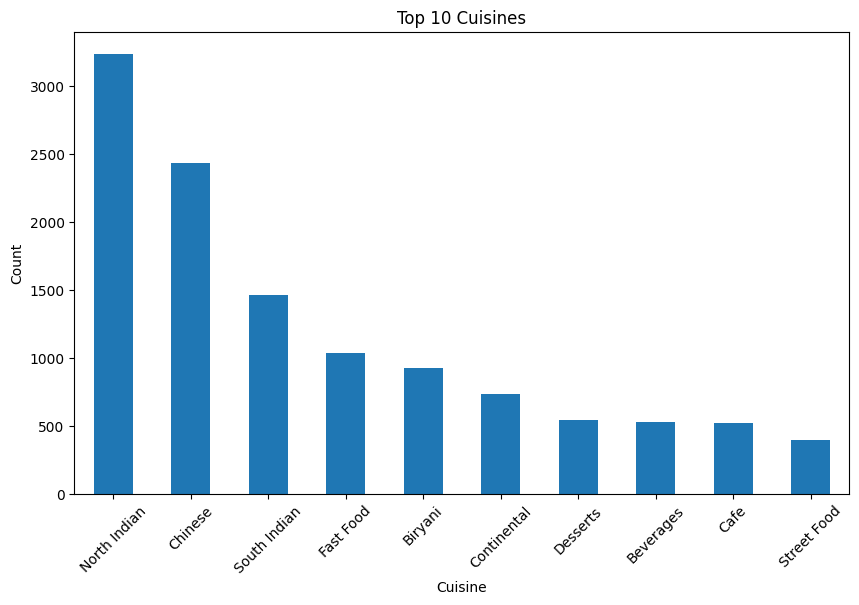


Rating summary:


,rating
count,7105.000000
mean,3.514117
std,0.461028
min,1.800000
25%,3.200000
50%,3.500000
75%,3.800000
max,4.900000


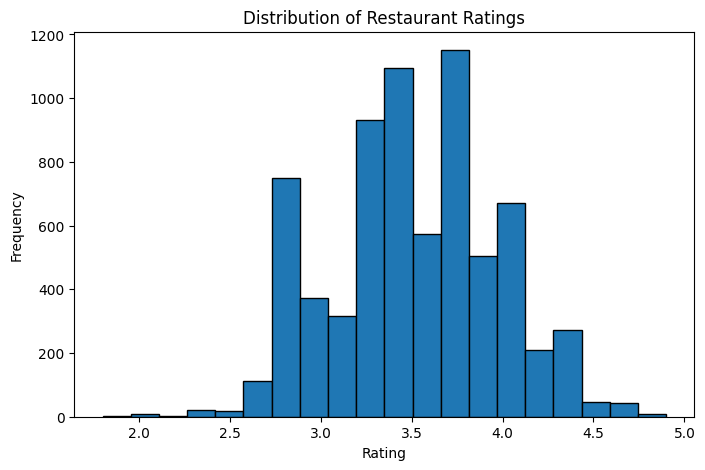


Average cost summary:


,avg_cost_for_two
count,7105.000000
mean,539.161013
std,461.211329
min,40.000000
25%,300.000000
50%,400.000000
75%,600.000000
max,6000.000000


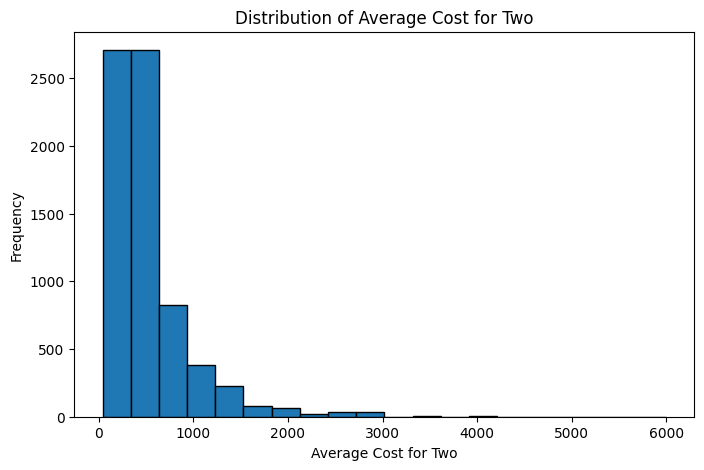


Rating category distribution:


,count
rating_category,
Low Rated,3052
Average Rated,2803
Highly Rated,1250


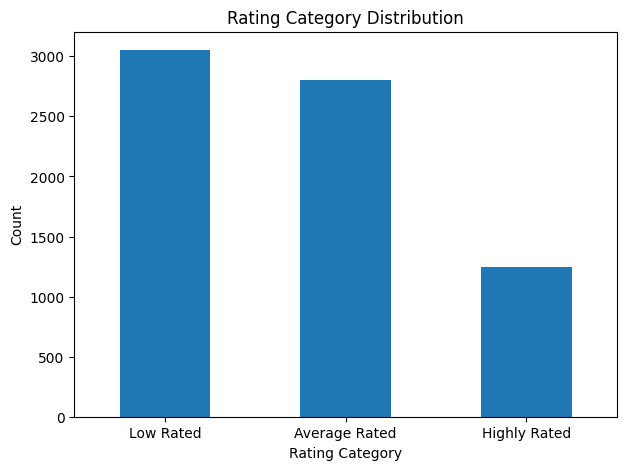


Cost category distribution:


,count
cost_category,
Budget,2708
Mid-range,2707
Expensive,1690


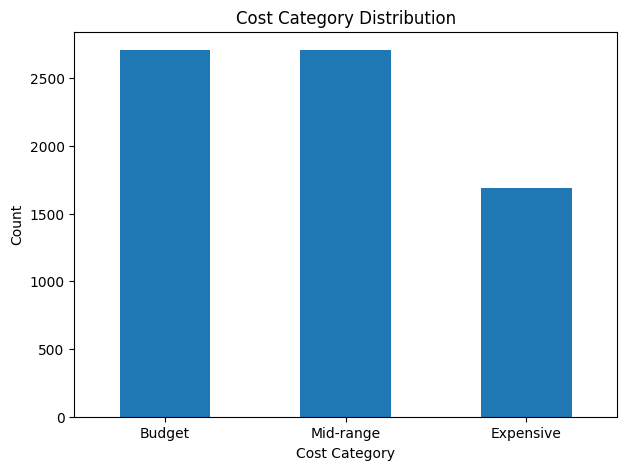


Popularity category distribution:


,count
popularity_category,
Low Popularity,5059
Medium Popularity,1459
High Popularity,587


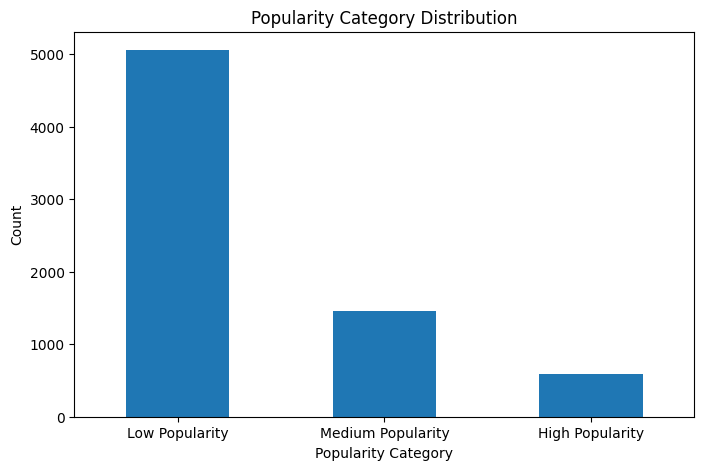


Average rating by online order:


,rating
online_order,
no,3.472439
yes,3.551892


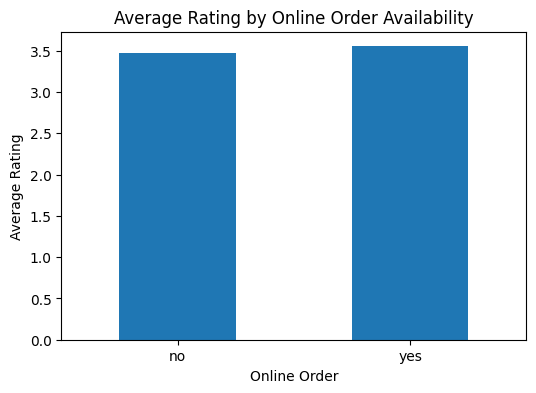


Average rating by table booking:


,rating
table_booking,
no,3.453073
yes,4.036022


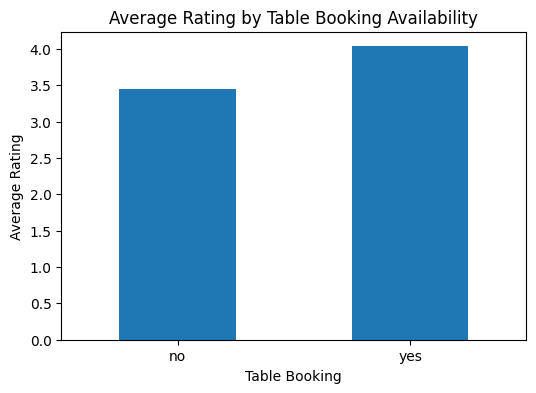


Top highly rated restaurants:


,restaurant_name,restaurant_type,rating,num_ratings,avg_cost_for_two,area
1035,Byg Brewski Brewing Company,Microbrewery,4.9,16345,1600.0,Bellandur
466,Asia Kitchen By Mainland China,"Casual Dining, Bar",4.9,2178,1500.0,"Byresandra,Tavarekere,Madiwala"
5271,SantÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃ...,Casual Dining,4.9,246,1000.0,Old Airport Road
6496,The Pizza Bakery,Casual Dining,4.8,1724,1200.0,Indiranagar
4444,O.G. Variar & Sons,Bakery,4.8,1156,200.0,Malleshwaram
4827,Punjab Grill,Casual Dining,4.8,650,2000.0,Whitefield
668,Belgian Waffle Factory,Dessert Parlor,4.8,186,400.0,"Byresandra,Tavarekere,Madiwala"
6665,Toit,Microbrewery,4.7,14956,1500.0,Indiranagar
6242,The Black Pearl,"Casual Dining, Bar",4.7,10413,1400.0,"Byresandra,Tavarekere,Madiwala"
2149,Flechazo,Casual Dining,4.7,7154,1400.0,Marathahalli


In [23]:
# ============================================================
# MODULE 5 - EXPLORATORY DATA ANALYSIS (EDA)
# ============================================================

# 5.1 Dataset overview
print("Shape of dataset:", df_clean.shape)
print("\nColumns:")
print(df_clean.columns.tolist())
display(df_clean.head())

# 5.2 Restaurant type distribution
restaurant_type_counts = df_clean['restaurant_type'].value_counts().head(10)
print("\nTop restaurant types:")
display(restaurant_type_counts)
plt.figure(figsize=(10,6))
restaurant_type_counts.plot(kind='bar')
plt.title('Top 10 Restaurant Types')
plt.xlabel('Restaurant Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

# 5.3 Online order distribution
online_order_counts = df_clean['online_order'].value_counts()
print("\nOnline order distribution:")
display(online_order_counts)
plt.figure(figsize=(6,4))
online_order_counts.plot(kind='bar')
plt.title('Online Order Availability')
plt.xlabel('Online Order')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

# 5.4 Table booking distribution
table_booking_counts = df_clean['table_booking'].value_counts()
print("\nTable booking distribution:")
display(table_booking_counts)
plt.figure(figsize=(6,4))
table_booking_counts.plot(kind='bar')
plt.title('Table Booking Availability')
plt.xlabel('Table Booking')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

# 5.5 Top areas
top_areas = df_clean['area'].value_counts().head(10)
print("\nTop 10 areas:")
display(top_areas)
plt.figure(figsize=(10,6))
top_areas.plot(kind='bar')
plt.title('Top 10 Areas with Most Restaurants')
plt.xlabel('Area')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

# 5.6 Top cuisines
all_cuisines = df_clean['cuisines_type'].dropna().str.split(',').sum()
all_cuisines = [c.strip() for c in all_cuisines]
cuisine_counts = pd.Series(all_cuisines).value_counts().head(10)
print("\nTop 10 cuisines:")
display(cuisine_counts)
plt.figure(figsize=(10,6))
cuisine_counts.plot(kind='bar')
plt.title('Top 10 Cuisines')
plt.xlabel('Cuisine')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

# 5.7 Rating distribution
print("\nRating summary:")
display(df_clean['rating'].describe())
plt.figure(figsize=(8,5))
plt.hist(df_clean['rating'], bins=20, edgecolor='black')
plt.title('Distribution of Restaurant Ratings')
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.show()

# 5.8 Average cost distribution
print("\nAverage cost summary:")
display(df_clean['avg_cost_for_two'].describe())
plt.figure(figsize=(8,5))
plt.hist(df_clean['avg_cost_for_two'], bins=20, edgecolor='black')
plt.title('Distribution of Average Cost for Two')
plt.xlabel('Average Cost for Two')
plt.ylabel('Frequency')
plt.show()

# 5.9 Rating category distribution
rating_cat_counts = df_clean['rating_category'].value_counts()
print("\nRating category distribution:")
display(rating_cat_counts)
plt.figure(figsize=(7,5))
rating_cat_counts.plot(kind='bar')
plt.title('Rating Category Distribution')
plt.xlabel('Rating Category')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

# 5.10 Cost category distribution
cost_cat_counts = df_clean['cost_category'].value_counts()
print("\nCost category distribution:")
display(cost_cat_counts)
plt.figure(figsize=(7,5))
cost_cat_counts.plot(kind='bar')
plt.title('Cost Category Distribution')
plt.xlabel('Cost Category')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

# 5.11 Popularity category distribution
popularity_counts = df_clean['popularity_category'].value_counts()
print("\nPopularity category distribution:")
display(popularity_counts)
plt.figure(figsize=(8,5))
popularity_counts.plot(kind='bar')
plt.title('Popularity Category Distribution')
plt.xlabel('Popularity Category')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

# 5.12 Online order vs rating
online_rating = df_clean.groupby('online_order')['rating'].mean()
print("\nAverage rating by online order:")
display(online_rating)
plt.figure(figsize=(6,4))
online_rating.plot(kind='bar')
plt.title('Average Rating by Online Order Availability')
plt.xlabel('Online Order')
plt.ylabel('Average Rating')
plt.xticks(rotation=0)
plt.show()

# 5.13 Table booking vs rating
table_rating = df_clean.groupby('table_booking')['rating'].mean()
print("\nAverage rating by table booking:")
display(table_rating)
plt.figure(figsize=(6,4))
table_rating.plot(kind='bar')
plt.title('Average Rating by Table Booking Availability')
plt.xlabel('Table Booking')
plt.ylabel('Average Rating')
plt.xticks(rotation=0)
plt.show()

# 5.14 Top highly rated restaurants
top_restaurants = df_clean.sort_values(
    by=['rating', 'num_ratings'],
    ascending=[False, False]
)[['restaurant_name', 'restaurant_type', 'rating', 'num_ratings', 'avg_cost_for_two', 'area']].head(10)

print("\nTop highly rated restaurants:")
display(top_restaurants)

# MODULE 6 – CORRELATION ANALYSIS + ADVANCED VISUALIZATIONS

Correlation Matrix:


,rating,num_ratings,avg_cost_for_two,online_order_flag,table_booking_flag,is_high_rated
rating,1.000000,0.380215,0.374133,0.086071,0.387185,0.664042
num_ratings,0.380215,1.000000,0.340297,0.026624,0.370152,0.426262
avg_cost_for_two,0.374133,0.340297,1.000000,-0.116444,0.604935,0.427463
online_order_flag,0.086071,0.026624,-0.116444,1.000000,-0.026024,0.035750
table_booking_flag,0.387185,0.370152,0.604935,-0.026024,1.000000,0.456468
is_high_rated,0.664042,0.426262,0.427463,0.035750,0.456468,1.000000


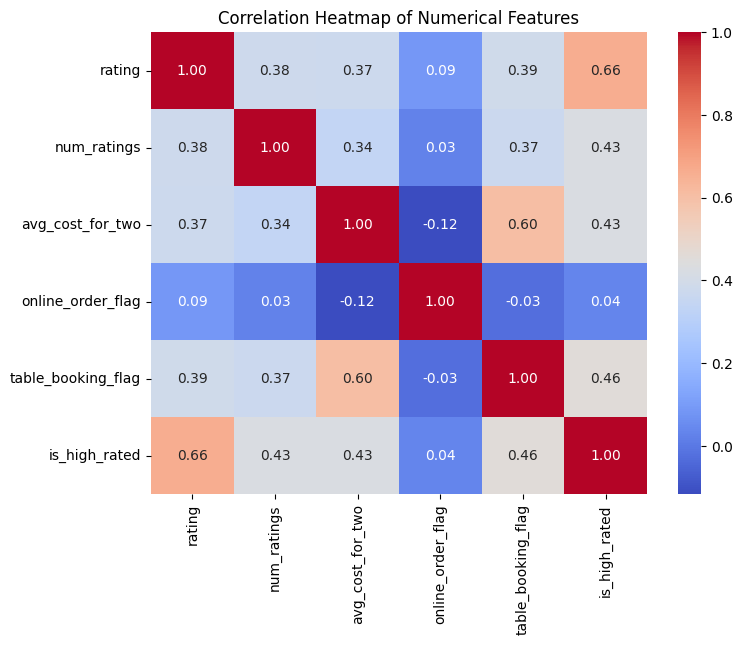

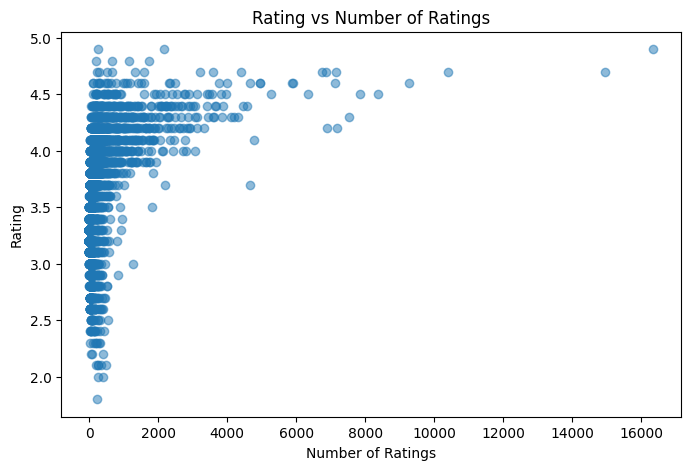

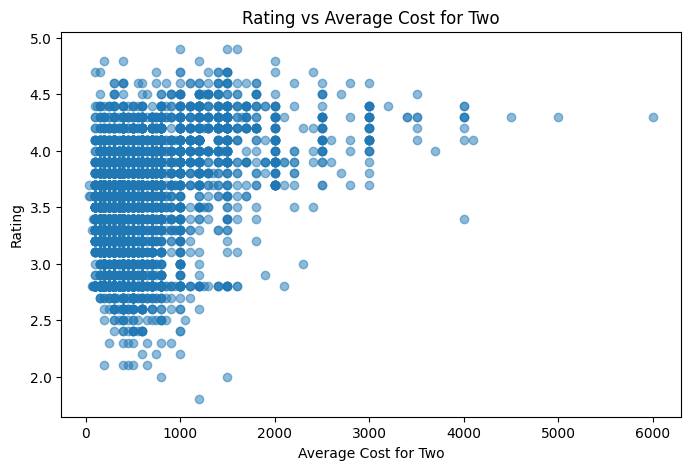

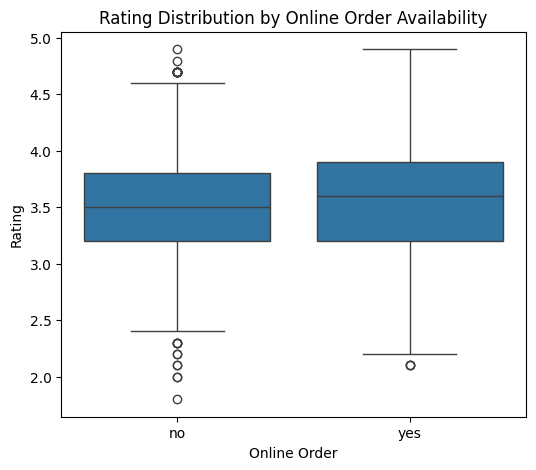

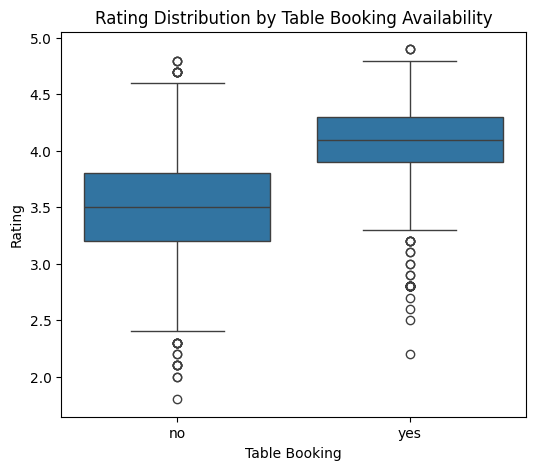

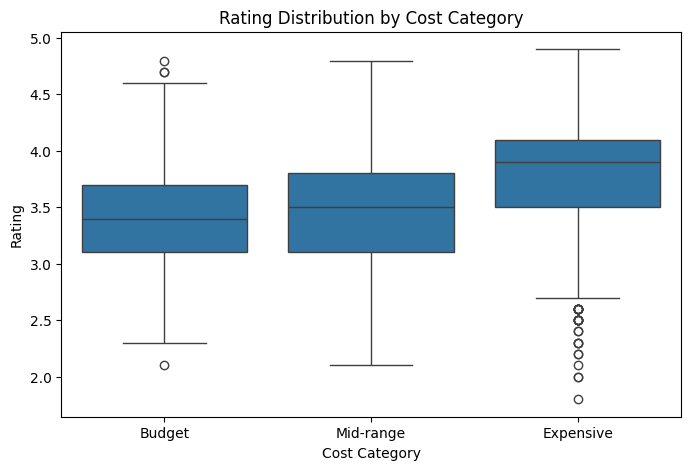

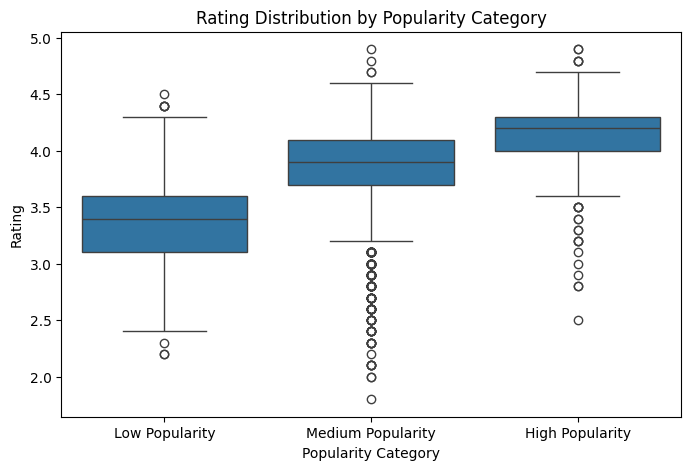


Top 10 restaurant types by average rating:


,rating
restaurant_type,
"Bar, Pub",4.6000
"Microbrewery, Pub",4.4625
"Casual Dining, Irani Cafee",4.4000
"Cafe, Lounge",4.4000
"Fine Dining, Lounge",4.4000
"Microbrewery, Bar",4.4000
"Pub, Microbrewery",4.4000
"Fine Dining, Microbrewery",4.3000
"Casual Dining, Microbrewery",4.2600


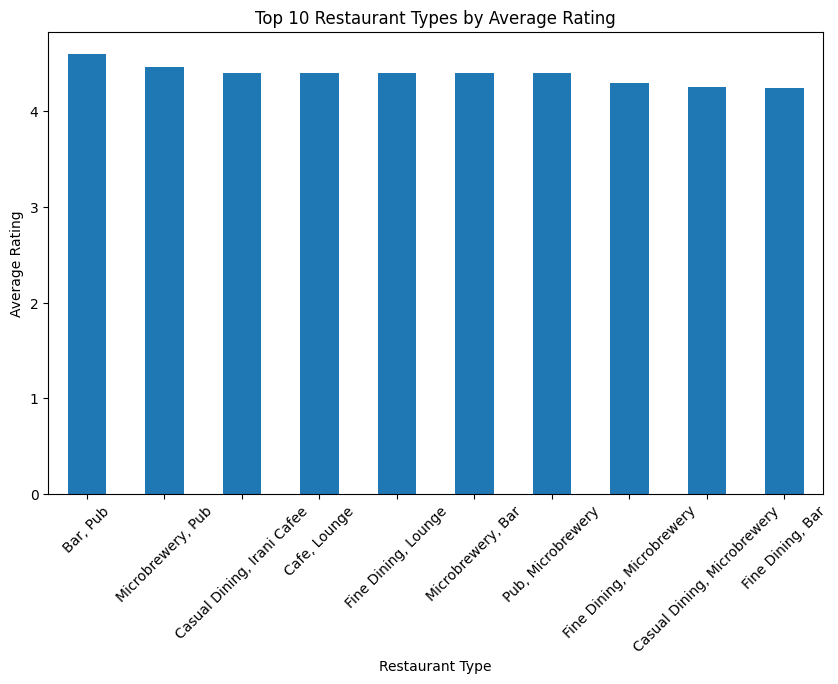


Top 10 restaurant types by average cost:


,avg_cost_for_two
restaurant_type,
"Fine Dining, Lounge",3000.000000
"Fine Dining, Microbrewery",3000.000000
"Fine Dining, Bar",2862.500000
Fine Dining,2784.810127
"Bar, Lounge",2450.000000
"Club, Casual Dining",2400.000000
"Lounge, Microbrewery",2000.000000
Club,1940.000000
"Lounge, Casual Dining",1866.666667


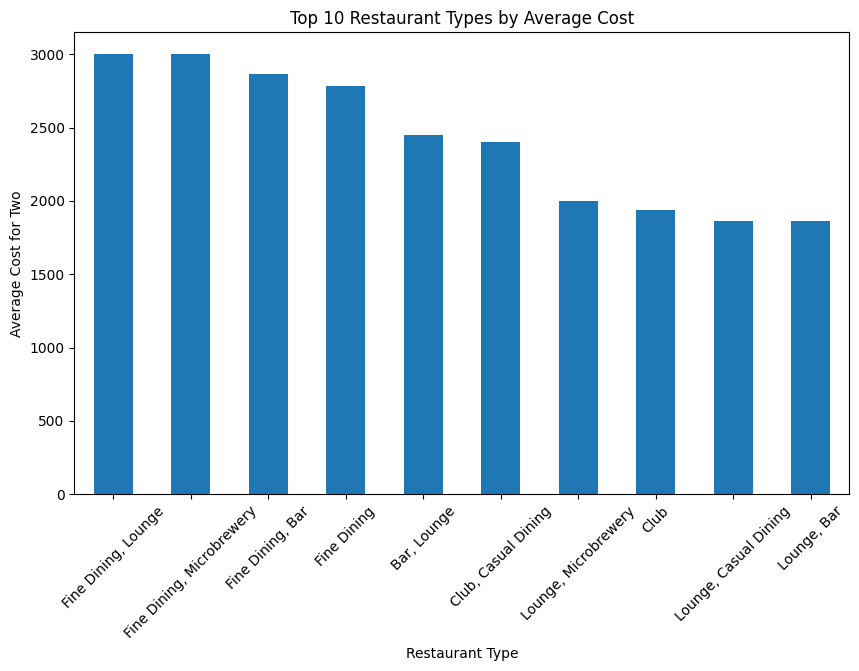


Correlation matrix saved as zomato_correlation_matrix.csv


In [24]:
# ============================================================
# MODULE 6 - CORRELATION ANALYSIS + ADVANCED VISUALIZATIONS
# ============================================================

# 6.1 Numerical columns
numeric_cols = [
    'rating',
    'num_ratings',
    'avg_cost_for_two',
    'online_order_flag',
    'table_booking_flag',
    'is_high_rated'
]

corr_df = df_clean[numeric_cols]

# 6.2 Correlation matrix
correlation_matrix = corr_df.corr()
print("Correlation Matrix:")
display(correlation_matrix)

# 6.3 Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

# 6.4 Rating vs number of ratings
plt.figure(figsize=(8,5))
plt.scatter(df_clean['num_ratings'], df_clean['rating'], alpha=0.5)
plt.title('Rating vs Number of Ratings')
plt.xlabel('Number of Ratings')
plt.ylabel('Rating')
plt.show()

# 6.5 Rating vs average cost
plt.figure(figsize=(8,5))
plt.scatter(df_clean['avg_cost_for_two'], df_clean['rating'], alpha=0.5)
plt.title('Rating vs Average Cost for Two')
plt.xlabel('Average Cost for Two')
plt.ylabel('Rating')
plt.show()

# 6.6 Rating by online order
plt.figure(figsize=(6,5))
sns.boxplot(x='online_order', y='rating', data=df_clean)
plt.title('Rating Distribution by Online Order Availability')
plt.xlabel('Online Order')
plt.ylabel('Rating')
plt.show()

# 6.7 Rating by table booking
plt.figure(figsize=(6,5))
sns.boxplot(x='table_booking', y='rating', data=df_clean)
plt.title('Rating Distribution by Table Booking Availability')
plt.xlabel('Table Booking')
plt.ylabel('Rating')
plt.show()

# 6.8 Rating by cost category
plt.figure(figsize=(8,5))
sns.boxplot(x='cost_category', y='rating', data=df_clean)
plt.title('Rating Distribution by Cost Category')
plt.xlabel('Cost Category')
plt.ylabel('Rating')
plt.show()

# 6.9 Rating by popularity category
plt.figure(figsize=(8,5))
sns.boxplot(x='popularity_category', y='rating', data=df_clean)
plt.title('Rating Distribution by Popularity Category')
plt.xlabel('Popularity Category')
plt.ylabel('Rating')
plt.show()

# 6.10 Avg rating by restaurant type
avg_rating_by_type = df_clean.groupby('restaurant_type')['rating'].mean().sort_values(ascending=False).head(10)
print("\nTop 10 restaurant types by average rating:")
display(avg_rating_by_type)
plt.figure(figsize=(10,6))
avg_rating_by_type.plot(kind='bar')
plt.title('Top 10 Restaurant Types by Average Rating')
plt.xlabel('Restaurant Type')
plt.ylabel('Average Rating')
plt.xticks(rotation=45)
plt.show()

# 6.11 Avg cost by restaurant type
avg_cost_by_type = df_clean.groupby('restaurant_type')['avg_cost_for_two'].mean().sort_values(ascending=False).head(10)
print("\nTop 10 restaurant types by average cost:")
display(avg_cost_by_type)
plt.figure(figsize=(10,6))
avg_cost_by_type.plot(kind='bar')
plt.title('Top 10 Restaurant Types by Average Cost')
plt.xlabel('Restaurant Type')
plt.ylabel('Average Cost for Two')
plt.xticks(rotation=45)
plt.show()

# 6.13 Save correlation matrix
correlation_matrix.to_csv('/content/zomato_correlation_matrix.csv')
print("\nCorrelation matrix saved as zomato_correlation_matrix.csv")

#MODULE 7 – INTERACTIVE FILTERS + USER PREFERENCE-BASED RESTAURANT FINDER

In [25]:
# ============================================================
# MODULE 7 - INTERACTIVE FILTERS + USER PREFERENCE-BASED RESTAURANT FINDER
# ============================================================

# 7.1 Check available values
print("Sample areas:")
print(sorted(df_clean['area'].dropna().unique())[:20])

print("\nSample online order values:")
print(df_clean['online_order'].dropna().unique())

print("\nSample table booking values:")
print(df_clean['table_booking'].dropna().unique())

# 7.2 Example filter by area
selected_area = 'BTM'
area_filtered = df_clean[df_clean['area'].str.lower() == selected_area.lower()]
print(f"\nRestaurants in {selected_area}: {area_filtered.shape[0]}")

# 7.3 Example filter by cuisine
selected_cuisine = 'Biryani'
cuisine_filtered = df_clean[
    df_clean['cuisines_type'].str.contains(selected_cuisine, case=False, na=False)
]
print(f"Restaurants serving {selected_cuisine}: {cuisine_filtered.shape[0]}")

# 7.7 Main restaurant finder function
def find_restaurants(data, area=None, cuisine=None, max_cost=None,
                     min_rating=None, online_order=None, table_booking=None,
                     top_n=10):
    filtered_data = data.copy()

    if area is not None:
        filtered_data = filtered_data[
            filtered_data['area'].str.contains(area, case=False, na=False)
        ]

    if cuisine is not None:
        filtered_data = filtered_data[
            filtered_data['cuisines_type'].str.contains(cuisine, case=False, na=False)
        ]

    if max_cost is not None:
        filtered_data = filtered_data[
            filtered_data['avg_cost_for_two'] <= max_cost
        ]

    if min_rating is not None:
        filtered_data = filtered_data[
            filtered_data['rating'] >= min_rating
        ]

    if online_order is not None:
        filtered_data = filtered_data[
            filtered_data['online_order'].str.lower() == online_order.lower()
        ]

    if table_booking is not None:
        filtered_data = filtered_data[
            filtered_data['table_booking'].str.lower() == table_booking.lower()
        ]

    filtered_data = filtered_data.sort_values(
        by=['rating', 'num_ratings'],
        ascending=[False, False]
    )

    return filtered_data.head(top_n)

# 7.8 Test cases
result_1 = find_restaurants(
    data=df_clean,
    area='BTM',
    cuisine='Biryani',
    max_cost=500,
    min_rating=4.0,
    online_order='yes',
    table_booking=None,
    top_n=10
)

print("\nTest Case 1 Results:")
display(result_1[['restaurant_name', 'restaurant_type', 'rating',
                  'num_ratings', 'avg_cost_for_two',
                  'online_order', 'table_booking',
                  'cuisines_type', 'area']])

result_2 = find_restaurants(
    data=df_clean,
    area='Indiranagar',
    cuisine='Chinese',
    max_cost=800,
    min_rating=3.8,
    online_order=None,
    table_booking='yes',
    top_n=10
)

print("\nTest Case 2 Results:")
display(result_2[['restaurant_name', 'restaurant_type', 'rating',
                  'num_ratings', 'avg_cost_for_two',
                  'online_order', 'table_booking',
                  'cuisines_type', 'area']])

result_3 = find_restaurants(
    data=df_clean,
    area=None,
    cuisine=None,
    max_cost=300,
    min_rating=4.2,
    online_order=None,
    table_booking=None,
    top_n=10
)

print("\nTest Case 3 Results:")
display(result_3[['restaurant_name', 'restaurant_type', 'rating',
                  'num_ratings', 'avg_cost_for_two',
                  'cuisines_type', 'area']])

# Save one result
result_1.to_csv('/content/sample_recommendation_result.csv', index=False)
print("\nSample recommendation result saved successfully.")

Sample areas:
['Banashankari', 'Bannerghatta Road', 'Basavanagudi', 'Bellandur', 'Brigade Road', 'Brookefield', 'Byresandra,Tavarekere,Madiwala', 'Church Street', 'Electronic City', 'Frazer Town', 'HSR', 'Indiranagar', 'JP Nagar', 'Jayanagar', 'Kalyan Nagar', 'Kammanahalli', 'Koramangala 4th Block', 'Koramangala 5th Block', 'Koramangala 6th Block', 'Koramangala 7th Block']

Sample online order values:
['no' 'yes']

Sample table booking values:
['no' 'yes']

Restaurants in BTM: 0
Restaurants serving Biryani: 929

Test Case 1 Results:


,restaurant_name,restaurant_type,rating,num_ratings,avg_cost_for_two,online_order,table_booking,cuisines_type,area



Test Case 2 Results:


,restaurant_name,restaurant_type,rating,num_ratings,avg_cost_for_two,online_order,table_booking,cuisines_type,area
3895,Meghana Foods,Casual Dining,4.2,1745,750.0,yes,yes,"Biryani, Chinese, North Indian, Seafood",Indiranagar



Test Case 3 Results:


,restaurant_name,restaurant_type,rating,num_ratings,avg_cost_for_two,cuisines_type,area
4444,O.G. Variar & Sons,Bakery,4.8,1156,200.0,"Bakery, Desserts",Malleshwaram
1631,CTR,Quick Bites,4.7,4408,150.0,South Indian,Malleshwaram
6024,Taaza Thindi,Quick Bites,4.7,651,100.0,South Indian,Banashankari
4064,Mugful Of Stories,Dessert Parlor,4.6,274,300.0,"Desserts, Bakery",Kalyan Nagar
6480,The Pancake Story,Dessert Parlor,4.6,117,300.0,"Desserts, Beverages","Byresandra,Tavarekere,Madiwala"
6832,Veena Stores,Quick Bites,4.5,2407,150.0,South Indian,Malleshwaram
2628,HOMMS,Quick Bites,4.5,224,300.0,"Chinese, Beverages, Momos, Thai",Brookefield
5367,Shakes Theory,Beverage Shop,4.5,155,300.0,"Beverages, Sandwich",Banashankari
2838,HVR Veg,Quick Bites,4.5,96,300.0,South Indian,Malleshwaram
6861,Vidyarthi Bhavan,Quick Bites,4.4,4460,150.0,South Indian,Banashankari



Sample recommendation result saved successfully.


#MODULE 8 – MACHINE LEARNING MODEL BUILDING

Confusion Matrix - Logistic Regression
[[1140   31]
 [ 124  126]]

Confusion Matrix - Decision Tree
[[1071  100]
 [  94  156]]

Confusion Matrix - Random Forest
[[1121   50]
 [  94  156]]

Model Comparison Table:


,Model,Accuracy,Precision,Recall,F1 Score
2,Random Forest,0.898663,0.757282,0.624,0.684211
0,Logistic Regression,0.890922,0.802548,0.504,0.619165
1,Decision Tree,0.863476,0.609375,0.624,0.616601


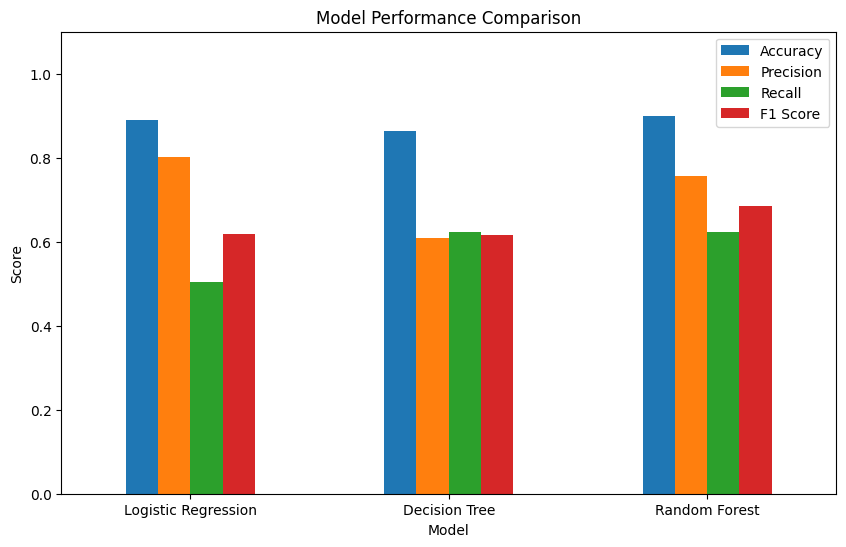


Random Forest Feature Importance:


,Feature,Importance
6,num_ratings,0.432830
1,avg_cost_for_two,0.157666
4,cuisines_type,0.146802
5,area,0.090868
3,table_booking,0.078732
0,restaurant_type,0.075034
2,online_order,0.018069


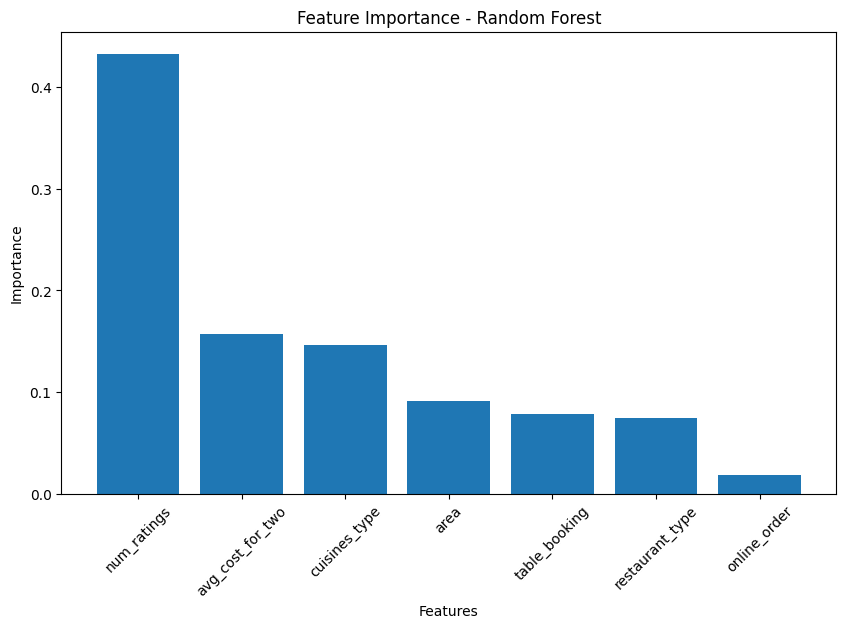


Model comparison and feature importance saved successfully.


In [26]:
# ============================================================
# MODULE 8 - MACHINE LEARNING MODEL BUILDING
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# 8.2 Select features and target
features = [
    'restaurant_type',
    'avg_cost_for_two',
    'online_order',
    'table_booking',
    'cuisines_type',
    'area',
    'num_ratings'
]

target = 'is_high_rated'

X = df_clean[features].copy()
y = df_clean[target].copy()

# 8.3 Encode categorical variables
X_encoded = X.copy()
label_encoders = {}

categorical_cols = [
    'restaurant_type',
    'online_order',
    'table_booking',
    'cuisines_type',
    'area'
]

for col in categorical_cols:
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(X_encoded[col].astype(str))
    label_encoders[col] = le

# 8.4 Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 8.5 Logistic Regression
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)
y_pred_log = log_model.predict(X_test)

log_accuracy = accuracy_score(y_test, y_pred_log)
log_precision = precision_score(y_test, y_pred_log)
log_recall = recall_score(y_test, y_pred_log)
log_f1 = f1_score(y_test, y_pred_log)

# 8.6 Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

dt_accuracy = accuracy_score(y_test, y_pred_dt)
dt_precision = precision_score(y_test, y_pred_dt)
dt_recall = recall_score(y_test, y_pred_dt)
dt_f1 = f1_score(y_test, y_pred_dt)

# 8.7 Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)

# 8.8 Confusion matrices
cm_log = confusion_matrix(y_test, y_pred_log)
cm_dt = confusion_matrix(y_test, y_pred_dt)
cm_rf = confusion_matrix(y_test, y_pred_rf)

print("Confusion Matrix - Logistic Regression")
print(cm_log)

print("\nConfusion Matrix - Decision Tree")
print(cm_dt)

print("\nConfusion Matrix - Random Forest")
print(cm_rf)

# 8.9 Model comparison
model_comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'Accuracy': [log_accuracy, dt_accuracy, rf_accuracy],
    'Precision': [log_precision, dt_precision, rf_precision],
    'Recall': [log_recall, dt_recall, rf_recall],
    'F1 Score': [log_f1, dt_f1, rf_f1]
})

print("\nModel Comparison Table:")
display(model_comparison.sort_values(by='Accuracy', ascending=False))

# 8.10 Visualize comparison
comparison_plot = model_comparison.set_index('Model')
comparison_plot[['Accuracy', 'Precision', 'Recall', 'F1 Score']].plot(
    kind='bar',
    figsize=(10,6)
)
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.ylim(0, 1.1)
plt.show()

# 8.11 Feature importance
feature_importance = pd.DataFrame({
    'Feature': X_encoded.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\nRandom Forest Feature Importance:")
display(feature_importance)

plt.figure(figsize=(10,6))
plt.bar(feature_importance['Feature'], feature_importance['Importance'])
plt.title('Feature Importance - Random Forest')
plt.xlabel('Features')
plt.ylabel('Importance')
plt.xticks(rotation=45)
plt.show()

# 8.12 Save results
model_comparison.to_csv('/content/zomato_model_comparison.csv', index=False)
feature_importance.to_csv('/content/zomato_feature_importance.csv', index=False)

print("\nModel comparison and feature importance saved successfully.")

#MODULE 9 – FINAL INSIGHTS, CONCLUSION & PROJECT SUMMARY

In [30]:
# ============================================================
# MODULE 9 - FINAL INSIGHTS, CONCLUSION & PROJECT SUMMARY
# ============================================================

print("===================================================")
print("        ZOMATO DATA ANALYSIS PROJECT SUMMARY       ")
print("===================================================\n")

print("Total number of restaurants :", df_clean.shape[0])
print("Total number of features    :", df_clean.shape[1])

print("\nUnique restaurant types :", df_clean['restaurant_type'].nunique())
print("Unique cuisines         :", df_clean['cuisines_type'].nunique())
print("Unique areas            :", df_clean['area'].nunique())

print("\nAverage restaurant rating      :", round(df_clean['rating'].mean(), 2))
print("Average cost for two people    :", round(df_clean['avg_cost_for_two'].mean(), 2))
print("Average number of ratings      :", round(df_clean['num_ratings'].mean(), 2))

print("\n===================================================")
print("                KEY EDA INSIGHTS                  ")
print("===================================================\n")

top_areas = df_clean['area'].value_counts().head(10)
print("Top 10 restaurant areas:")
display(top_areas)

top_restaurant_types = df_clean['restaurant_type'].value_counts().head(10)
print("\nTop 10 restaurant types:")
display(top_restaurant_types)

top_cuisines = df_clean['cuisines_type'].value_counts().head(10)
print("\nTop 10 cuisines:")
display(top_cuisines)

avg_rating_by_type = df_clean.groupby('restaurant_type')['rating'].mean().sort_values(ascending=False).head(10)
print("\nTop restaurant types by average rating:")
display(avg_rating_by_type)

avg_cost_by_area = df_clean.groupby('area')['avg_cost_for_two'].mean().sort_values(ascending=False).head(10)
print("\nTop 10 expensive areas based on average cost for two:")
display(avg_cost_by_area)

print("\n===================================================")
print("              CORRELATION INSIGHTS                ")
print("===================================================\n")

numeric_cols = ['rating', 'num_ratings', 'avg_cost_for_two']
corr_matrix = df_clean[numeric_cols].corr()

print("Correlation Matrix:")
display(corr_matrix)

rating_num_corr = corr_matrix.loc['rating', 'num_ratings']
rating_cost_corr = corr_matrix.loc['rating', 'avg_cost_for_two']
cost_num_corr = corr_matrix.loc['avg_cost_for_two', 'num_ratings']

print(f"Correlation between rating and number of ratings: {rating_num_corr:.3f}")
print(f"Correlation between rating and average cost for two: {rating_cost_corr:.3f}")
print(f"Correlation between average cost and number of ratings: {cost_num_corr:.3f}")

print("\n===================================================")
print("         MACHINE LEARNING MODEL SUMMARY           ")
print("===================================================\n")

print("Model Comparison Table:")
display(model_comparison)

best_model_row = model_comparison.sort_values(by='Accuracy', ascending=False).iloc[0]

best_model_name = best_model_row['Model']
best_model_accuracy = best_model_row['Accuracy']
best_model_precision = best_model_row['Precision']
best_model_recall = best_model_row['Recall']
best_model_f1 = best_model_row['F1 Score']

print("\nBest Performing Model:")
print("Model Name :", best_model_name)
print("Accuracy   :", round(best_model_accuracy, 4))
print("Precision  :", round(best_model_precision, 4))
print("Recall     :", round(best_model_recall, 4))
print("F1 Score   :", round(best_model_f1, 4))

print("\n===================================================")
print("            BUSINESS / PRACTICAL INSIGHTS         ")
print("===================================================\n")

most_common_area = df_clean['area'].value_counts().idxmax()
most_common_area_count = df_clean['area'].value_counts().max()

most_common_type = df_clean['restaurant_type'].value_counts().idxmax()
most_common_type_count = df_clean['restaurant_type'].value_counts().max()

highest_rated_type = df_clean.groupby('restaurant_type')['rating'].mean().sort_values(ascending=False).index[0]
highest_rated_type_rating = df_clean.groupby('restaurant_type')['rating'].mean().sort_values(ascending=False).iloc[0]

most_expensive_area = df_clean.groupby('area')['avg_cost_for_two'].mean().sort_values(ascending=False).index[0]
most_expensive_area_cost = df_clean.groupby('area')['avg_cost_for_two'].mean().sort_values(ascending=False).iloc[0]

print(f"1. The area with the highest number of restaurants is '{most_common_area}' with {most_common_area_count} restaurants.")
print(f"2. The most common restaurant type in the dataset is '{most_common_type}' with {most_common_type_count} restaurants.")
print(f"3. The restaurant type with the highest average rating is '{highest_rated_type}' with an average rating of {highest_rated_type_rating:.2f}.")
print(f"4. The most expensive area based on average cost for two is '{most_expensive_area}' with an average cost of {most_expensive_area_cost:.2f}.")
print(f"5. The best machine learning model for predicting highly rated restaurants is '{best_model_name}'.")

print("\n===================================================")
print("                  FINAL CONCLUSION                ")
print("===================================================\n")

print("This project analyzed the Zomato restaurant dataset to understand restaurant patterns,")
print("customer-related trends, pricing behavior, restaurant distribution across areas,")
print("and factors influencing restaurant ratings.")
print()
print("The dataset was cleaned, transformed, and explored using data analysis techniques.")
print("Visualizations were used to identify important trends in restaurant types, cuisines,")
print("areas, ratings, and average cost for two people.")
print()
print("A machine learning classification task was also performed to predict whether a")
print("restaurant is highly rated or not. Among the models tested, the best performing")
print(f"model was '{best_model_name}' with an accuracy of {best_model_accuracy:.4f}.")
print()
print("Overall, this project demonstrates how restaurant data can be analyzed to extract")
print("valuable business insights and support decision-making using data science techniques.")

print("\n===================================================")
print("                   FUTURE SCOPE                   ")
print("===================================================\n")

future_scope_points = [
    "1. Build a full restaurant recommendation system based on user preferences.",
    "2. Use advanced machine learning models such as XGBoost or Gradient Boosting.",
    "3. Add sentiment analysis using customer reviews if review text data is available.",
    "4. Build an interactive dashboard using Streamlit, Power BI, or Tableau.",
    "5. Deploy the project as a web application for real-time restaurant search and analysis."
]

for point in future_scope_points:
    print(point)

top_areas.to_csv('/content/zomato_top_areas.csv')
top_restaurant_types.to_csv('/content/zomato_top_restaurant_types.csv')
top_cuisines.to_csv('/content/zomato_top_cuisines.csv')
avg_rating_by_type.to_csv('/content/zomato_avg_rating_by_type.csv')
avg_cost_by_area.to_csv('/content/zomato_avg_cost_by_area.csv')

print("\nFinal summary files saved successfully.")

        ZOMATO DATA ANALYSIS PROJECT SUMMARY       

Total number of restaurants : 7105
Total number of features    : 16

Unique restaurant types : 81
Unique cuisines         : 2175
Unique areas            : 30

Average restaurant rating      : 3.51
Average cost for two people    : 539.16
Average number of ratings      : 188.92

                KEY EDA INSIGHTS                  

Top 10 restaurant areas:


,count
area,
"Byresandra,Tavarekere,Madiwala",798
Bannerghatta Road,552
Brookefield,477
Brigade Road,464
Indiranagar,455
Electronic City,403
Malleshwaram,402
Kalyan Nagar,384
Bellandur,361



Top 10 restaurant types:


,count
restaurant_type,
Quick Bites,2840
Casual Dining,1634
Cafe,403
Delivery,358
"Takeaway, Delivery",289
Dessert Parlor,217
Bakery,154
"Casual Dining, Bar",123
Beverage Shop,118



Top 10 cuisines:


...


              CORRELATION INSIGHTS                

Correlation Matrix:


,rating,num_ratings,avg_cost_for_two
rating,1.000000,0.380215,0.374133
num_ratings,0.380215,1.000000,0.340297
avg_cost_for_two,0.374133,0.340297,1.000000


Correlation between rating and number of ratings: 0.380
Correlation between rating and average cost for two: 0.374
Correlation between average cost and number of ratings: 0.340

         MACHINE LEARNING MODEL SUMMARY           

Model Comparison Table:


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.890922,0.802548,0.504,0.619165
1,Decision Tree,0.863476,0.609375,0.624,0.616601
2,Random Forest,0.898663,0.757282,0.624,0.684211



Best Performing Model:
Model Name : Random Forest
Accuracy   : 0.8987
Precision  : 0.7573
Recall     : 0.624
F1 Score   : 0.6842

            BUSINESS / PRACTICAL INSIGHTS         

1. The area with the highest number of restaurants is 'Byresandra,Tavarekere,Madiwala' with 798 restaurants.
2. The most common restaurant type in the dataset is 'Quick Bites' with 2840 restaurants.
3. The restaurant type with the highest average rating is 'Bar, Pub' with an average rating of 4.60.
4. The most expensive area based on average cost for two is 'Lavelle Road' with an average cost of 860.64.
5. The best machine learning model for predicting highly rated restaurants is 'Random Forest'.

                  FINAL CONCLUSION                

This project analyzed the Zomato restaurant dataset to understand restaurant patterns,
customer-related trends, pricing behavior, restaurant distribution across areas,
and factors influencing restaurant ratings.

The dataset was cleaned, transformed, and explore